# Berry--Esseen rates in one-dimensional Wasserstein distance

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2025 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:statistical-berry-esseen-w1`. Let $\alpha_0$ be centered with unit variance and define
$$
\alpha_n=(D_{1/\sqrt n})_\sharp\alpha_0^{*n},
\qquad n\geq 1.
$$
We compare the exact numerical error $\mathcal{W}_1(\alpha_n,\gamma)$ to the Berry--Esseen scaling
$$
\mathcal{W}_1(\alpha_n,\gamma)
\leq C\,m_3(\alpha_0)n^{-1/2},
\qquad
m_3(\alpha_0)=\int |x|^3\,\mathrm d\alpha_0(x),
$$
for the symmetric Bernoulli law and a standardized law uniform on 101 equally spaced points.

In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('IPython', 'ipython'),
    ('scipy', 'scipy'),
)
_OT4ML_REQUIRED_FILES = (

)
ROOT = _OT4ML_STYLE.configure_notebook(
    packages=_OT4ML_PACKAGES,
    required_files=_OT4ML_REQUIRED_FILES,
)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.signal import fftconvolve
from scipy.special import ndtr, ndtri

from figure_style import (
    BLUE,
    GRAY,
    LIGHT_GRAY,
    RED,
    VIOLET,
    box_axes,
    figure_dir,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

FIGURE_NAME = "statistical-berry-esseen-w1"
OUT = figure_dir(FIGURE_NAME)
THUMBNAIL = ROOT / "notebooks-figures" / "thumbnails" / f"{FIGURE_NAME}.png"
THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)

## Exact $\mathcal{W}_1$ evaluation

For a discrete law $\alpha=\sum_i w_i\delta_{x_i}$, the quantile formula gives
$$
\mathcal{W}_1(\alpha,\gamma)
=
\sum_i\int_{s_{i-1}}^{s_i}|x_i-\Phi^{-1}(u)|\,\mathrm du,
\qquad
s_i=\sum_{j\leq i}w_j.
$$
The antiderivative $\int \Phi^{-1}(u)\,\mathrm du=-\phi(\Phi^{-1}(u))$ makes this computation exact up to floating-point arithmetic.

In [3]:
def gaussian_pdf(x):
    """Evaluate the standard Gaussian density.

    Args:
        x: Scalar or array of evaluation points.

    Returns:
        Standard Gaussian density evaluated at ``x``.
    """
    x = np.asarray(x, dtype=float)
    return np.exp(-0.5 * x**2) / np.sqrt(2.0 * np.pi)


def gaussian_quantile_primitive(u):
    """Evaluate an antiderivative of the standard Gaussian quantile.

    The continuous extension of ``-phi(Phi^{-1}(u))`` is zero at both
    endpoints of ``[0, 1]``.

    Args:
        u: Quantile levels in ``[0, 1]``.

    Returns:
        Values of the quantile antiderivative at ``u``.
    """
    u = np.asarray(u, dtype=float)
    values = np.zeros_like(u)
    interior = (u > 0.0) & (u < 1.0)
    values[interior] = -gaussian_pdf(ndtri(u[interior]))
    return values


def discrete_gaussian_w1(support, weights):
    """Compute ``W_1`` between a one-dimensional discrete law and ``N(0, 1)``.

    Args:
        support: One-dimensional support locations.
        weights: Nonnegative masses associated with ``support``.

    Returns:
        The exact quantile-integral value up to floating-point arithmetic.
    """
    support = np.asarray(support, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(support)
    support = support[order]
    weights = np.maximum(weights[order], 0.0)
    weights /= weights.sum()

    upper = np.cumsum(weights)
    upper[-1] = 1.0
    lower = np.concatenate(([0.0], upper[:-1]))
    crossing = np.clip(ndtr(support), lower, upper)

    left = (
        support * (crossing - lower)
        - gaussian_quantile_primitive(crossing)
        + gaussian_quantile_primitive(lower)
    )
    right = (
        gaussian_quantile_primitive(upper)
        - gaussian_quantile_primitive(crossing)
        - support * (upper - crossing)
    )
    return float(np.sum(left + right))

## Normalized convolution laws

Both inputs live on regular one-dimensional grids. Repeated FFT convolution therefore computes every $\alpha_n$ without sampling noise. The 101-point uniform law is recentered and rescaled numerically so that its variance is exactly one.

In [4]:
def normalized_convolution_laws(base_support, base_weights, n_max):
    """Compute normalized convolution powers of a regular-grid discrete law.

    Args:
        base_support: Equally spaced support of the centered input law.
        base_weights: Probability masses on ``base_support``.
        n_max: Largest convolution order to compute.

    Returns:
        Dictionary mapping each ``n`` to the support and weights of
        ``(D_{1/sqrt(n)})_# alpha_0^{*n}``.

    Raises:
        ValueError: If the support is not a nontrivial regular grid.
    """
    base_support = np.asarray(base_support, dtype=float)
    base_weights = np.asarray(base_weights, dtype=float)
    if base_support.ndim != 1 or base_support.size < 2:
        raise ValueError("base_support must be a one-dimensional regular grid")
    steps = np.diff(base_support)
    if not np.allclose(steps, steps[0], rtol=1e-10, atol=1e-12):
        raise ValueError("base_support must be equally spaced")

    base_weights = np.maximum(base_weights, 0.0)
    base_weights /= base_weights.sum()
    step = float(steps[0])
    origin = float(base_support[0])
    coefficients = np.array([1.0])
    laws = {}

    for n in range(1, n_max + 1):
        coefficients = fftconvolve(coefficients, base_weights)
        coefficients = np.maximum(coefficients, 0.0)
        coefficients /= coefficients.sum()
        support = (n * origin + step * np.arange(coefficients.size)) / np.sqrt(n)
        laws[n] = (support, coefficients.copy())
    return laws


def standardized_uniform_grid(point_count):
    """Construct a centered unit-variance law uniform on a dense grid.

    Args:
        point_count: Number of equally weighted support points.

    Returns:
        Pair ``(support, weights)`` defining the standardized law.
    """
    support = np.linspace(-1.0, 1.0, point_count)
    weights = np.full(point_count, 1.0 / point_count)
    support -= np.dot(weights, support)
    support /= np.sqrt(np.dot(weights, support**2))
    return support, weights


N_MAX = 160
bernoulli_support = np.array([-1.0, 1.0])
bernoulli_weights = np.array([0.5, 0.5])
uniform_support, uniform_weights = standardized_uniform_grid(101)

bernoulli_laws = normalized_convolution_laws(
    bernoulli_support, bernoulli_weights, N_MAX
)
uniform_laws = normalized_convolution_laws(
    uniform_support, uniform_weights, N_MAX
)

n_values = np.arange(1, N_MAX + 1)
bernoulli_errors = np.array(
    [discrete_gaussian_w1(*bernoulli_laws[n]) for n in n_values]
)
uniform_errors = np.array(
    [discrete_gaussian_w1(*uniform_laws[n]) for n in n_values]
)
bernoulli_m3 = float(np.dot(bernoulli_weights, np.abs(bernoulli_support) ** 3))
uniform_m3 = float(np.dot(uniform_weights, np.abs(uniform_support) ** 3))

def validate_normalization(laws, name):
    """Check mass, mean, and variance along normalized convolution powers.

    Args:
        laws: Dictionary of discrete normalized convolution laws.
        name: Human-readable law name used in assertion messages.

    Returns:
        None. An assertion fails if a normalization invariant is violated.
    """
    for n, (support, weights) in laws.items():
        mass = float(weights.sum())
        mean = float(np.dot(weights, support))
        variance = float(np.dot(weights, (support - mean) ** 2))
        assert np.isclose(mass, 1.0, atol=2e-12), f"{name}, n={n}: mass={mass}"
        assert abs(mean) <= 2e-10, f"{name}, n={n}: mean={mean}"
        assert np.isclose(variance, 1.0, atol=2e-9), f"{name}, n={n}: variance={variance}"


validate_normalization(bernoulli_laws, "Bernoulli")
validate_normalization(uniform_laws, "101-point uniform")


print(f"Bernoulli m3={bernoulli_m3:.6f}, W1(n=160)={bernoulli_errors[-1]:.6f}")
print(f"101-point uniform m3={uniform_m3:.6f}, W1(n=160)={uniform_errors[-1]:.6f}")

Bernoulli m3=1.000000, W1(n=160)=0.039546
101-point uniform m3=1.298974, W1(n=160)=0.000817


## Rendering

The first two panels show $\alpha_0$ together with the normalized two- and six-fold convolutions. In the rate panel, solid curves are numerical $\mathcal{W}_1$ values and dashed curves are $m_3(\alpha_0)/\sqrt n$, corresponding to the theorem with the universal constant set to $C=1$. The theorem allows a fixed additional vertical factor $C$.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


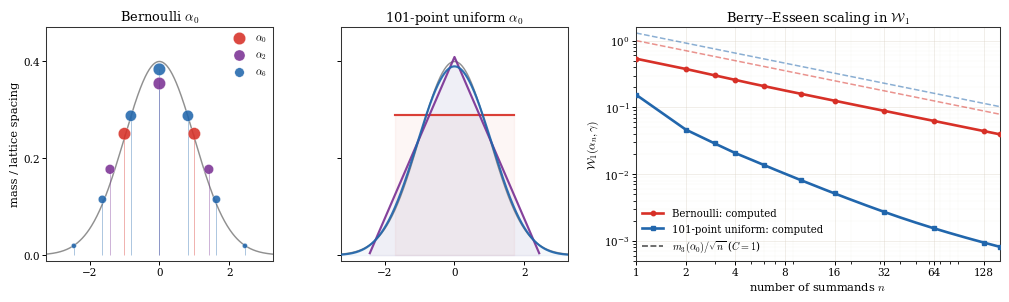

In [5]:
SNAPSHOT_ORDERS = (1, 2, 6)
SNAPSHOT_LABELS = (r"$\alpha_0$", r"$\alpha_2$", r"$\alpha_6$")
SNAPSHOT_COLORS = (RED, VIOLET, BLUE)


def draw_snapshot_panel(ax, laws, title, *, draw_stems):
    """Draw selected normalized convolution laws in one compact panel.

    Args:
        ax: Matplotlib axis receiving the curves.
        laws: Dictionary returned by ``normalized_convolution_laws``.
        title: Panel title.
        draw_stems: Whether to emphasize atoms with stems and markers.

    Returns:
        None. The supplied axis is modified in place.
    """
    grid = np.linspace(-3.35, 3.35, 700)
    ax.plot(grid, gaussian_pdf(grid), color=GRAY, lw=1.05, alpha=0.62, zorder=1)

    for n, label, color in zip(SNAPSHOT_ORDERS, SNAPSHOT_LABELS, SNAPSHOT_COLORS):
        support, weights = laws[n]
        spacing = float(np.median(np.diff(support)))
        heights = weights / spacing
        if draw_stems:
            ax.vlines(support, 0.0, heights, color=color, lw=0.65, alpha=0.40, zorder=2)
            sizes = 7.0 + 72.0 * (heights / heights.max()) ** 0.8
            ax.scatter(
                support,
                heights,
                s=sizes,
                color=color,
                edgecolor="white",
                linewidth=0.25,
                alpha=0.88,
                label=label,
                zorder=3,
            )
        else:
            ax.plot(support, heights, color=color, lw=1.55, alpha=0.92, label=label, zorder=3)
            ax.fill_between(support, 0.0, heights, color=color, alpha=0.045, zorder=2)

    ax.set_title(title, fontsize=9.4, pad=4)
    ax.set_xlim(-3.25, 3.25)
    ax.set_ylim(-0.012, 0.47)
    ax.set_xticks([-2, 0, 2])
    ax.set_yticks([0.0, 0.2, 0.4])
    ax.tick_params(labelsize=7.5, pad=1.5)
    box_axes(ax)


fig = plt.figure(figsize=(10.2, 3.25))
grid_spec = fig.add_gridspec(1, 3, width_ratios=(1.28, 1.28, 2.05), wspace=0.25)
axes = [fig.add_subplot(grid_spec[0, index]) for index in range(3)]

# Sparse atoms make the lattice effect visible; the 101-point law is rendered
# as a density curve to avoid an unreadable forest of stems.
draw_snapshot_panel(axes[0], bernoulli_laws, r"Bernoulli $\alpha_0$", draw_stems=True)
draw_snapshot_panel(axes[1], uniform_laws, r"101-point uniform $\alpha_0$", draw_stems=False)
axes[0].set_ylabel("mass / lattice spacing", fontsize=8.2, labelpad=2)
axes[1].set_yticklabels([])
axes[0].legend(loc="upper right", frameon=False, fontsize=7.4, handlelength=1.4, borderpad=0.1)

rate_ax = axes[2]
marker_indices = np.array([0, 1, 2, 3, 5, 9, 15, 31, 63, 127, 159])
rate_ax.loglog(
    n_values,
    bernoulli_errors,
    color=RED,
    lw=1.9,
    marker="o",
    markevery=marker_indices,
    ms=3.2,
    label="Bernoulli: computed",
    zorder=4,
)
rate_ax.loglog(
    n_values,
    uniform_errors,
    color=BLUE,
    lw=1.9,
    marker="s",
    markevery=marker_indices,
    ms=3.0,
    label="101-point uniform: computed",
    zorder=4,
)
rate_ax.loglog(
    n_values,
    bernoulli_m3 / np.sqrt(n_values),
    color=RED,
    lw=1.1,
    ls="--",
    alpha=0.52,
    zorder=2,
)
rate_ax.loglog(
    n_values,
    uniform_m3 / np.sqrt(n_values),
    color=BLUE,
    lw=1.1,
    ls="--",
    alpha=0.52,
    zorder=2,
)
rate_ax.set_title(r"Berry--Esseen scaling in $\mathcal{W}_1$", fontsize=9.4, pad=4)
rate_ax.set_xlabel(r"number of summands $n$", fontsize=8.2, labelpad=2)
rate_ax.set_ylabel(r"$\mathcal{W}_1(\alpha_n,\gamma)$", fontsize=8.2, labelpad=2)
rate_ax.set_xlim(1.0, N_MAX)
rate_ax.set_ylim(5e-4, 1.6)
rate_ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 128])
rate_ax.set_xticklabels(["1", "2", "4", "8", "16", "32", "64", "128"])
rate_ax.grid(True, which="major", color=LIGHT_GRAY, lw=0.45, alpha=0.58)
rate_ax.grid(True, which="minor", color=LIGHT_GRAY, lw=0.25, alpha=0.24)
rate_ax.tick_params(labelsize=7.5, pad=1.5)
box_axes(rate_ax)

legend_handles, legend_labels = rate_ax.get_legend_handles_labels()
legend_handles.append(Line2D([0], [0], color=GRAY, lw=1.15, ls="--"))
legend_labels.append(r"$m_3(\alpha_0)/\sqrt{n}$ ($C=1$)")
rate_ax.legend(
    legend_handles,
    legend_labels,
    loc="lower left",
    frameon=False,
    fontsize=7.3,
    handlelength=2.1,
    borderpad=0.1,
)

fig.subplots_adjust(left=0.06, right=0.995, bottom=0.18, top=0.90)
save_pdf(fig, OUT / "comparison.pdf", pad_inches=0.025)
fig.savefig(THUMBNAIL, dpi=220, bbox_inches="tight", pad_inches=0.025)
plt.show()
plt.close(fig)